In [2]:
import pandas as pd

df = pd.read_csv('IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))

/tmp/ipykernel_1074/2941936103.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


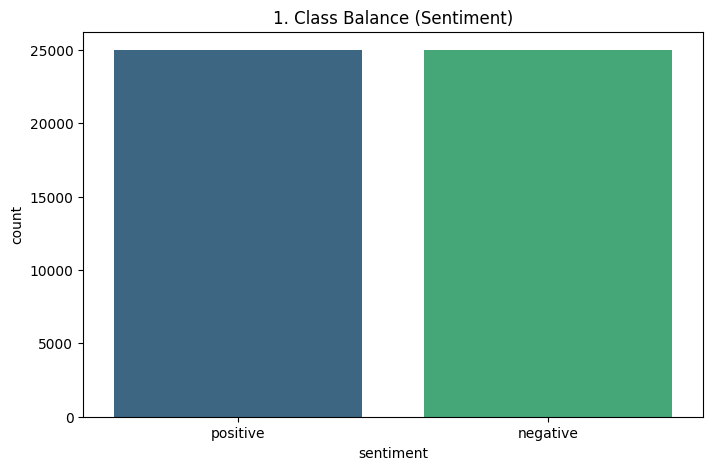

In [4]:
plt.figure(figsize=(8, 5)) 
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('1. Class Balance (Sentiment)')
plt.show()

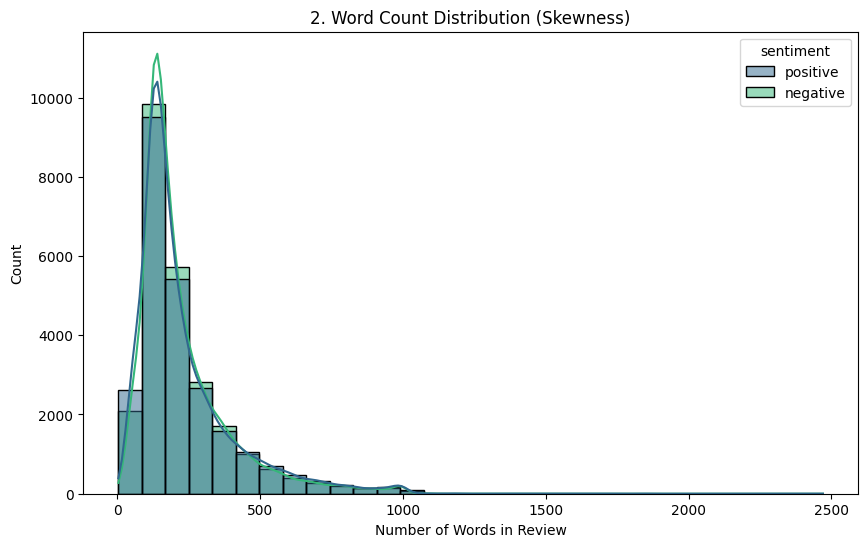

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='word_count', hue='sentiment', kde=True, bins=30, palette='viridis')
plt.title('2. Word Count Distribution (Skewness)')
plt.xlabel('Number of Words in Review')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_1074/4293493877.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sentiment', y='word_count', data=df, palette='viridis')


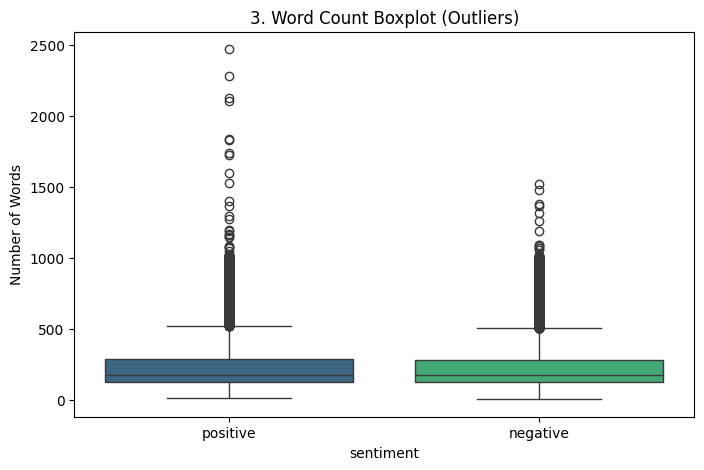

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='sentiment', y='word_count', data=df, palette='viridis')
plt.title('3. Word Count Boxplot (Outliers)')
plt.ylabel('Number of Words')
plt.show()

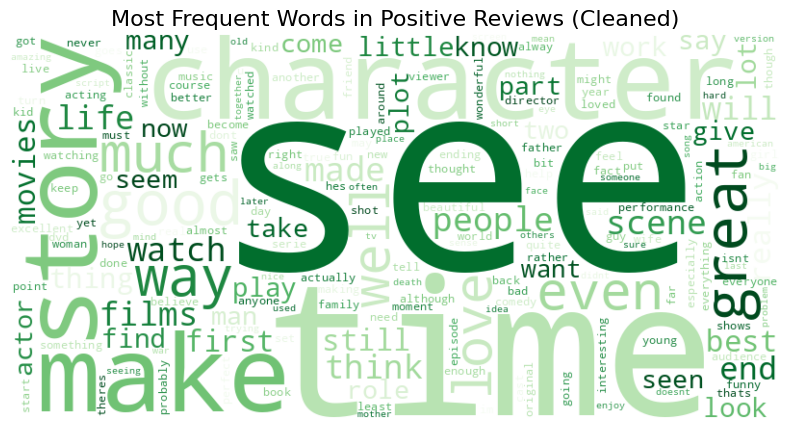

In [15]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS 


positive_text_cleaned = " ".join(review for review in df[df['sentiment'] == 'positive']['clean_review'].astype(str))


my_stopwords = set(STOPWORDS)
my_stopwords.update(['br', 'movie', 'film', 'one', 'show', 'like']) 


wordcloud_pos_cleaned = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Greens',
    stopwords=my_stopwords 
).generate(positive_text_cleaned)


plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos_cleaned, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Positive Reviews (Cleaned)', fontsize=16)
plt.show()

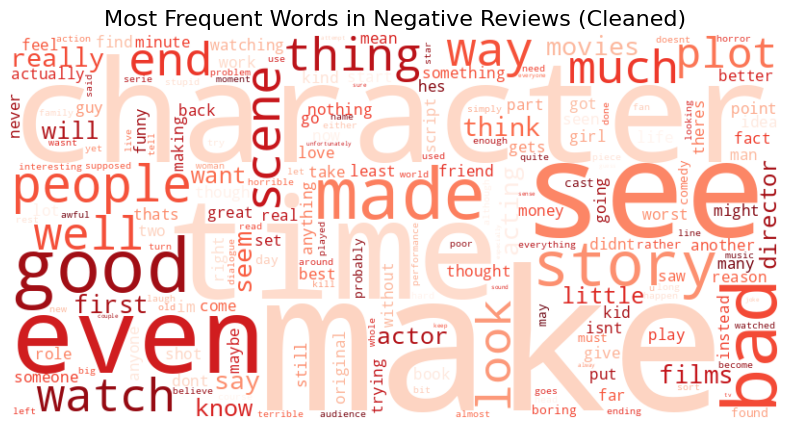

In [16]:

negative_text_cleaned = " ".join(review for review in df[df['sentiment'] == 'negative']['clean_review'].astype(str))




wordcloud_neg_cleaned = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds',           
    stopwords=my_stopwords     
).generate(negative_text_cleaned)


plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg_cleaned, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Negative Reviews (Cleaned)', fontsize=16)
plt.show()

In [11]:
import re

# Function to clean raw text
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)         # Remove HTML tags like <br />
    text = re.sub(r'[^\w\s]', '', text)        # Remove all punctuations
    return text.lower()                        # Convert all characters to lowercase

# Apply the function to create a new cleaned column
df['clean_review'] = df['review'].apply(clean_text)

# Change 'positive'/'negative' text to numbers (1/0)
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [12]:
from sklearn.model_selection import train_test_split

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'], 
    df['label'], 
    test_size=0.2, 
    random_state=42
)

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text to numbers and REMOVE English stop words automatically
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

# Learn vocabulary from training data and transform it
X_train_vec = vectorizer.fit_transform(X_train)

# Only transform the test data (do not fit)
X_test_vec = vectorizer.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the model
model = LogisticRegression()
model.fit(X_train_vec, y_train)

# Test the model and print the results
predictions = model.predict(X_test_vec)

print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
print(classification_report(y_test, predictions))

Accuracy: 0.8870
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.87      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [9]:
import joblib

# Export model and vectorizer as files
joblib.dump(model, 'sentiment_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("Model and Vectorizer exported successfully!")

Model and Vectorizer exported successfully!
